Initialisation projet + dossier de travail

In [1]:
from pathlib import Path
import os
import warnings

# Racine du projet
PROJECT_ROOT = Path.cwd() / "house_prices_project"

# Arborescence du projet
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

for path in [PROJECT_ROOT, DATA_DIR, RAW_DIR, INTERIM_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

print("Projet initialisé avec succès.")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"RAW_DIR      : {RAW_DIR}")

Projet initialisé avec succès.
PROJECT_ROOT : c:\Users\ghood\Desktop\DataScience\house_prices_project
RAW_DIR      : c:\Users\ghood\Desktop\DataScience\house_prices_project\data\raw


In [2]:
import zipfile
from pathlib import Path

zip_path = Path("data/raw/house-prices-advanced-regression-techniques.zip")
extract_path = Path("data/raw")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("Décompression terminée.")
print([p.name for p in extract_path.iterdir()])

Décompression terminée.
['data_description.txt', 'house-prices-advanced-regression-techniques.zip', 'sample_submission.csv', 'test.csv', 'train.csv']


Chargement des fichiers

In [3]:
import pandas as pd

train = pd.read_csv("data/raw/train.csv")
test = pd.read_csv("data/raw/test.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

train shape: (1460, 81)
test shape : (1459, 80)


In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**1. Analyse des valeurs manquantes**

In [6]:
missing_df = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_pct": train.isna().mean() * 100,
    "dtype": train.dtypes
})

missing_df = missing_df[missing_df["missing_count"] > 0] \
    .sort_values(by="missing_pct", ascending=False)

missing_df.head(20)

,missing_count,missing_pct,dtype
PoolQC,1453,99.520548,object
MiscFeature,1406,96.301370,object
Alley,1369,93.767123,object
Fence,1179,80.753425,object
MasVnrType,872,59.726027,object
FireplaceQu,690,47.260274,object
LotFrontage,259,17.739726,float64
GarageType,81,5.547945,object
GarageYrBlt,81,5.547945,float64
GarageFinish,81,5.547945,object


---

In [7]:
fill_none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]
train[fill_none_cols] = train[fill_none_cols].fillna("None")

**Interprétation** :
*Les variables comme `PoolQC`, `MiscFeature`, `Alley` et `Fence` présentent un taux de valeurs manquantes très élevé (>80%).*
*Ces valeurs manquantes ne sont pas dues à des erreurs mais à l'absence réelle de ces équipements dans la majorité des logements.*
*Par exemple, une valeur manquante dans PoolQC signifie que la maison ne possède pas de piscine.*
*Ces variables contiennent donc une information importante et seront encodées par une catégorie "None" plutôt que supprimées.*

---

In [8]:
train["FireplaceQu"] = train["FireplaceQu"].fillna("None")
train["MasVnrType"] = train["MasVnrType"].fillna("None")

**Interprétation** :
*Les variables comme `MasVnrType` et `FireplaceQu` présentent un taux de valeurs manquantes significatif.*
*Cela correspond généralement à l'absence de certains éléments (ex : pas de cheminée).*
*Ces valeurs manquantes sont donc informatives et seront remplacées par "None".*
*Cela permet de conserver l'information structurelle dans le modèle.*

---

In [9]:
train["LotFrontage"] = train.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

**Interprétation**:
*La variable `LotFrontage` contient environ 17% de valeurs manquantes.*
*Contrairement aux précédentes, ces valeurs ne représentent pas une absence, mais plutôt un manque d'information. Cette variable dépend* *fortement du quartier (Neighborhood), il est donc pertinent d'imputer les valeurs manquantes par la médiane du quartier.*
*Cette approche permet de conserver la cohérence spatiale des données.*

---

In [10]:
garage_cols = ["GarageType", "GarageFinish"]
train[garage_cols] = train[garage_cols].fillna("None")

train["GarageYrBlt"] = train["GarageYrBlt"].fillna(0)

**Interprétation** :
*Les variables liées au garage présentent un faible taux de valeurs manquantes (~5%).*
*Ces valeurs manquantes correspondent généralement à des logements sans garage.*
*Elles seront donc remplacées par "None" pour les variables catégorielles, et par 0 pour les variables numériques (ex : année de construction du garage).*

---

**2. Analyse de la target**

In [11]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

*La variable `SalePrice` présente une moyenne (~180k) supérieure à la médiane (~163k), ce qui indique une distribution asymétrique vers la droite. Cela signifie que quelques maisons très chères tirent la moyenne vers le haut.*
*La majorité des biens se situe donc dans une gamme de prix inférieure à la moyenne.*

In [12]:
import sys
sys.executable

'c:\\Users\\ghood\\AppData\\Local\\Programs\\Python\\Python311\\python.exe'

In [13]:
!pip show seaborn


Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: c:\Users\ghood\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages
Requires: matplotlib, numpy, pandas
Required-by: 


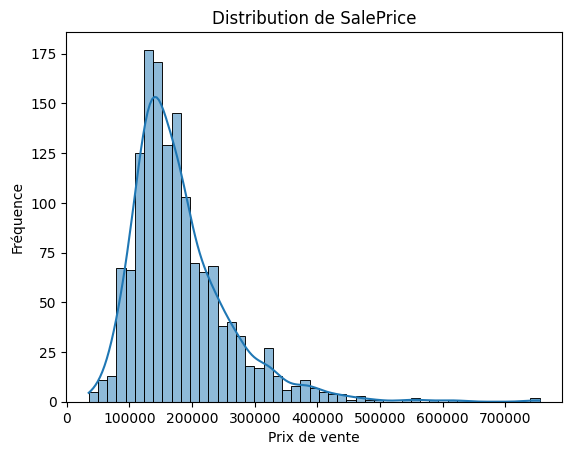

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution de SalePrice")
plt.xlabel("Prix de vente")
plt.ylabel("Fréquence")
plt.show()

**Distribution de la variable cible (SalePrice)**

L’histogramme de `SalePrice` montre une distribution asymétrique vers la droite.

On observe :
- une concentration importante de valeurs dans les prix moyens
- une longue queue à droite correspondant à des biens très chers
- la présence potentielle de valeurs extrêmes (outliers)

Cette asymétrie confirme les résultats statistiques précédents (skewness élevée),
et justifie l’application d’une transformation logarithmique.

In [15]:
train["SalePrice"].skew()

np.float64(1.8828757597682129)

*La skewness de `SalePrice` est d’environ 1.88, ce qui indique une forte asymétrie positive.*
*Cela signifie que la distribution possède une longue queue à droite, avec des valeurs extrêmes élevées (maisons de luxe).*
*Selon les règles statistiques, une skewness > 1 indique une asymétrie forte. Cette situation peut impacter négativement les modèles de régression, qui supposent souvent une distribution proche de la normale.*

**Synthèse** :  
La distribution de la variable cible `SalePrice`n’est pas normale.
Elle est fortement asymétrique à droite avec des outliers importants.
Une transformation logarithmique est donc nécessaire pour :
- réduire l’influence des valeurs extrêmes
- stabiliser la variance
- améliorer la performance des modèles

---

In [16]:
import numpy as np

train["SalePrice_log"] = np.log1p(train["SalePrice"])
train["SalePrice_log"].skew()

np.float64(0.12134661989685333)

Transformation de la variable cible (log)

La variable `SalePrice` présente une forte asymétrie positive (skewness ≈ 1.88), ce qui indique la présence de valeurs extrêmes élevées.

Afin de corriger cette asymétrie, une transformation logarithmique (`log1p`) a été appliquée. Cette transformation permet de :

- Réduire l’influence des valeurs extrêmes
- Stabiliser la variance
- Rendre la distribution plus proche d’une loi normale
- Améliorer les performances des modèles de régression

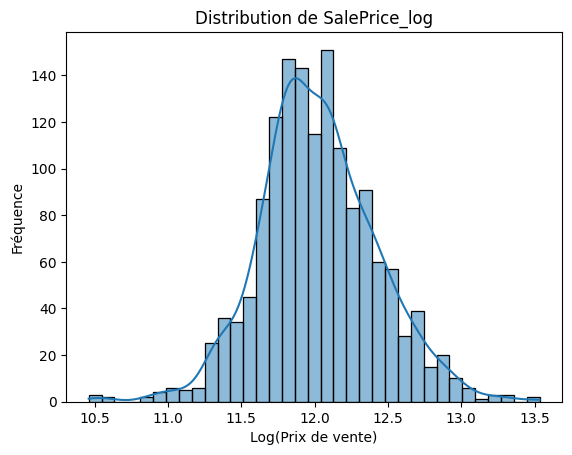

In [17]:
plt.figure()
sns.histplot(train["SalePrice_log"], kde=True)
plt.title("Distribution de SalePrice_log")
plt.xlabel("Log(Prix de vente)")
plt.ylabel("Fréquence")
plt.show()

**Distribution après transformation logarithmique**

Après transformation logarithmique, la distribution de `SalePrice_log` est beaucoup plus symétrique.

On observe :
- une forme proche d’une distribution normale (gaussienne)
- une réduction de la dispersion des valeurs extrêmes
- une meilleure homogénéité des données

Cette transformation améliore les conditions d’apprentissage pour les modèles de régression.

---

Analyse univariée de `SalePrice_log`  
*On va identifier les variables les plus liées à la target.*

In [18]:
corr = train.corr(numeric_only=True)["SalePrice_log"].sort_values(ascending=False)
corr.head(10)

SalePrice_log    1.000000
SalePrice        0.948374
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
Name: SalePrice_log, dtype: float64

**Sélection des variables les plus corrélées à la cible**

Cette étape permet d’identifier les variables numériques les plus liées à `SalePrice_log`.

L’objectif est de repérer les features les plus influentes avant de passer à l’analyse visuelle bivariée.

Les variables présentant les corrélations positives les plus fortes seront étudiées en priorité avec des scatter plots, car elles sont susceptibles d’avoir un impact important sur le prix de vente.

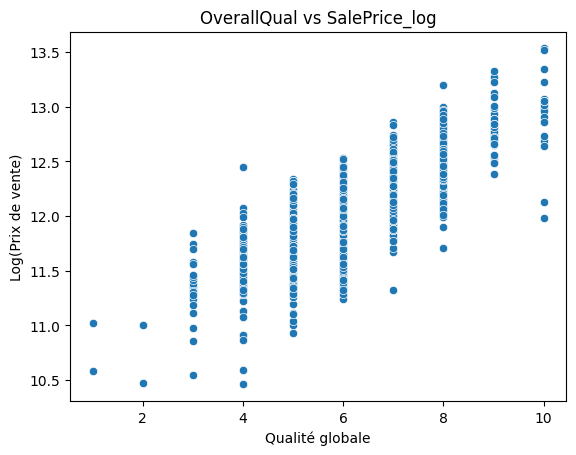

In [19]:
#la plus correléé 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.scatterplot(x=train["OverallQual"], y=train["SalePrice_log"])
plt.title("OverallQual vs SalePrice_log")
plt.xlabel("Qualité globale")
plt.ylabel("Log(Prix de vente)")
plt.show()

**Relation entre OverallQual et SalePrice_log**

Le nuage de points montre une relation positive claire entre la qualité globale du bien (`OverallQual`) et le prix de vente.

On observe que :
- plus la qualité du bien augmente, plus le prix de vente est élevé
- la relation semble quasi linéaire
- les biens de faible qualité sont concentrés dans les prix bas

Cela confirme que `OverallQual` est une variable fortement explicative du prix immobilier.

Cette variable sera donc essentielle dans la modélisation.

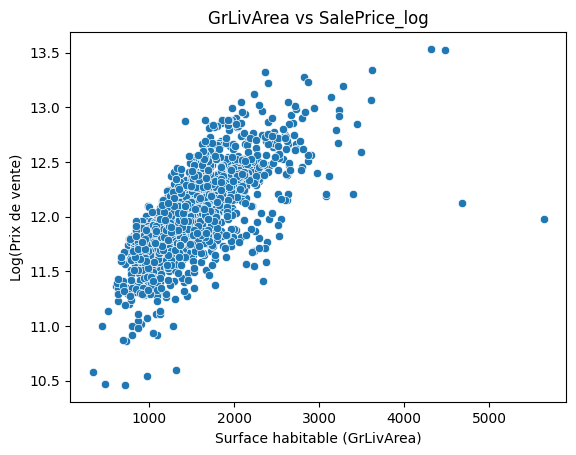

In [20]:
#Scatter plot avec GrLivArea
plt.figure()
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice_log"])
plt.title("GrLivArea vs SalePrice_log")
plt.xlabel("Surface habitable (GrLivArea)")
plt.ylabel("Log(Prix de vente)")
plt.show()

**Relation entre GrLivArea et SalePrice_log**

Le nuage de points montre une relation positive entre la surface habitable (`GrLivArea`) et le prix de vente.

On observe que :
- plus la surface habitable augmente, plus le prix de vente augmente
- la relation est globalement linéaire
- certains points semblent atypiques (grandes surfaces avec prix relativement faibles)

Ces observations suggèrent la présence possible d’outliers, qui pourraient perturber la modélisation.

La variable `GrLivArea` apparaît comme un facteur clé dans la détermination du prix immobilier.

**Detection des outliers**  
*On réutilise GrLivArea (très révélateur)*

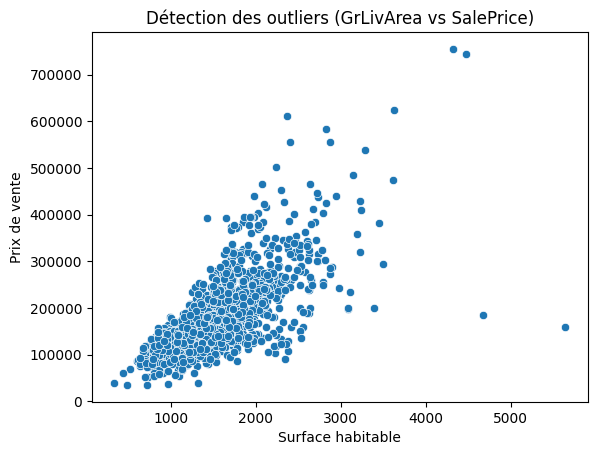

In [21]:
plt.figure()
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.title("Détection des outliers (GrLivArea vs SalePrice)")
plt.xlabel("Surface habitable")
plt.ylabel("Prix de vente")
plt.show()

**Détection des valeurs aberrantes (outliers)**

Le nuage de points met en évidence une relation globale positive entre la surface habitable et le prix.

Cependant, on observe des points atypiques :
- certaines maisons ont une très grande surface (GrLivArea élevée)
- mais un prix de vente anormalement faible

Ces observations correspondent à des outliers.

Ces valeurs aberrantes peuvent :
- biaiser les modèles de régression
- réduire la performance globale du modèle
- fausser l’estimation des relations entre variables

Il est donc pertinent d’envisager leur suppression ou leur traitement.

In [22]:
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
outliers

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
523,524,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,...,None,None,None,0,10,2007,New,Partial,184750,12.126764
1298,1299,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,...,Gd,None,None,0,1,2008,New,Partial,160000,11.982935


**Analyse des valeurs aberrantes (outliers)**

Deux observations présentent une surface habitable très élevée (> 4000)
mais un prix de vente relativement faible.

Ces points sont atypiques car, en pratique, une grande surface est généralement associée à un prix élevé.

Ces valeurs peuvent être dues à :
- des erreurs de données
- des cas particuliers (biens atypiques, ventes anormales)
- des situations non représentatives du marché

Ces outliers peuvent fortement perturber les modèles de régression,
notamment en influençant la pente de la relation entre les variables.

Il est donc pertinent de les supprimer afin d’améliorer la robustesse du modèle.

In [23]:
train = train.drop(outliers.index)

In [24]:
train.shape

(1458, 82)

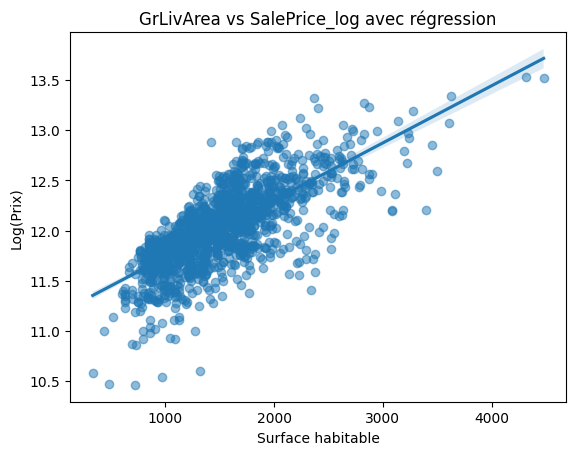

In [25]:
plt.figure()
sns.regplot(x=train["GrLivArea"], y=train["SalePrice_log"], scatter_kws={"alpha":0.5})
plt.title("GrLivArea vs SalePrice_log avec régression")
plt.xlabel("Surface habitable")
plt.ylabel("Log(Prix)")
plt.show()

**Relation entre GrLivArea et SalePrice_log avec régression**

Le graphique met en évidence une relation positive entre la surface habitable (`GrLivArea`) et le prix de vente (transformé en log).

On observe que :
- la droite de régression est croissante → plus la surface augmente, plus le prix augmente
- la relation est globalement linéaire, ce qui est favorable pour les modèles de régression
- la majorité des points est concentrée autour de la droite → bonne cohérence globale

Cependant :
- une certaine dispersion est visible, indiquant que d’autres variables influencent également le prix
- quelques points éloignés subsistent, suggérant la présence de variabilité non expliquée

Conclusion :
`GrLivArea` est une variable fortement explicative du prix immobilier,
mais elle ne suffit pas seule à expliquer toute la variance.

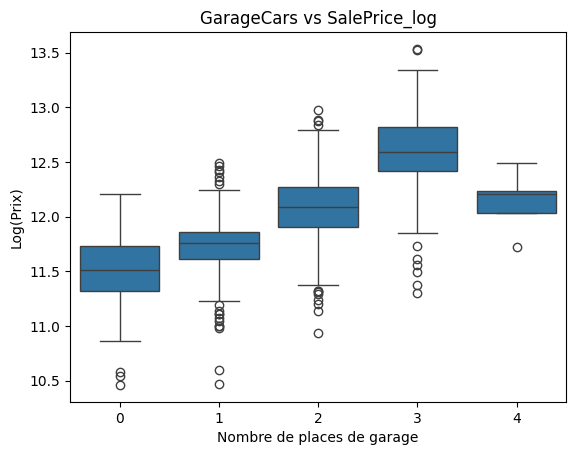

In [26]:
#quantitative vs quantitave
plt.figure()
sns.boxplot(x=train["GarageCars"], y=train["SalePrice_log"])
plt.title("GarageCars vs SalePrice_log")
plt.xlabel("Nombre de places de garage")
plt.ylabel("Log(Prix)")
plt.show()

**Relation entre GarageCars et SalePrice_log**

Le boxplot montre la distribution du prix de vente (log) en fonction du nombre de places de garage (`GarageCars`).

On observe que :
- le prix médian augmente avec le nombre de places de garage
- les maisons sans garage ont globalement des prix plus faibles
- chaque augmentation du nombre de places est associée à une hausse du prix

Cependant :
- la dispersion reste importante au sein de chaque groupe
- certains chevauchements existent entre les catégories

Conclusion :
`GarageCars` a un impact positif sur le prix de vente,
mais cet effet est moins précis qu’une variable continue comme `GrLivArea`.

Cette variable reste néanmoins très informative pour la modélisation.

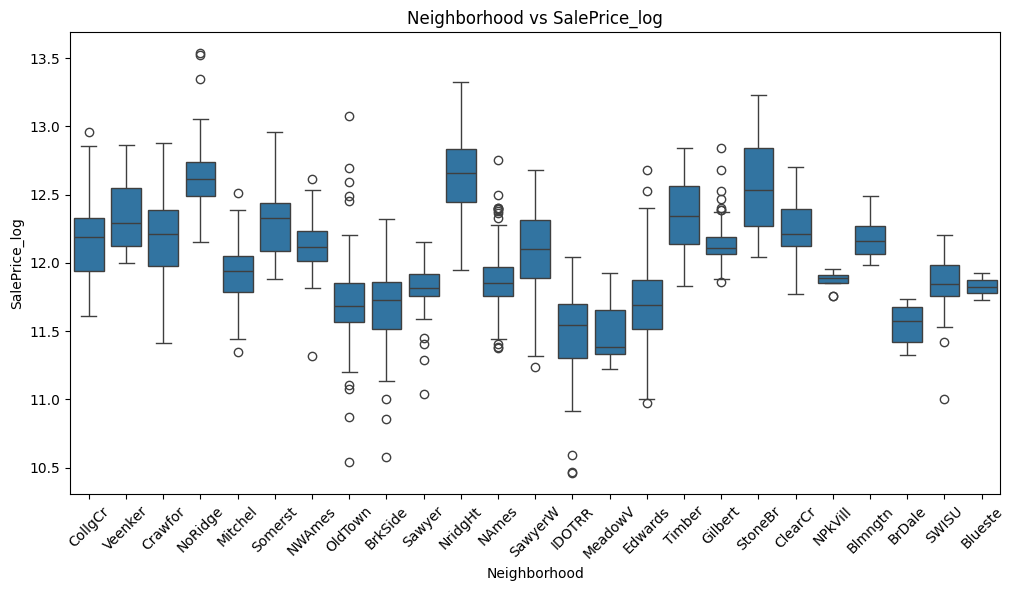

In [27]:
#categorielle
plt.figure(figsize=(12,6))
sns.boxplot(x=train["Neighborhood"], y=train["SalePrice_log"])
plt.xticks(rotation=45)
plt.title("Neighborhood vs SalePrice_log")
plt.show()

**Relation entre Neighborhood et SalePrice_log**

Le boxplot montre la distribution du prix de vente (log) selon les différents quartiers (`Neighborhood`).

On observe que :
- certains quartiers présentent des prix médians nettement plus élevés (ex : NridgHt, StoneBr, Timber)
- d’autres quartiers ont des prix significativement plus faibles (ex : IDOTRR, MeadowV)
- il existe une forte variabilité des prix selon la localisation

Cela indique que :
- la localisation est un facteur déterminant dans le prix immobilier
- certains quartiers sont clairement plus valorisés que d’autres

Cependant :
- une dispersion est observée à l’intérieur de chaque quartier
- ce qui montre que d’autres variables (surface, qualité, etc.) influencent également le prix

Conclusion :
`Neighborhood` est une variable catégorielle très importante,
et devra être encodée avec soin (ex : target encoding ou one-hot encoding).

**Mutlicolinéarité entres variables**

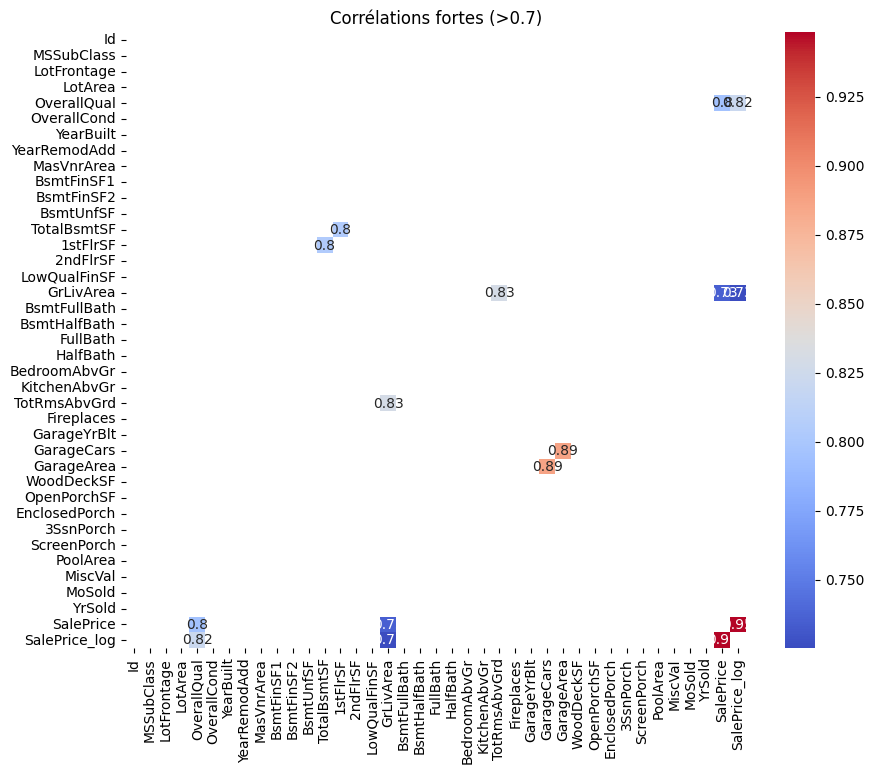

In [28]:
corr_matrix = train.corr(numeric_only=True)

high_corr = corr_matrix[(corr_matrix > 0.7) & (corr_matrix < 1.0)]

plt.figure(figsize=(10,8))
sns.heatmap(high_corr, annot=True, cmap="coolwarm")
plt.title("Corrélations fortes (>0.7)")
plt.show()
plt.show()

**Analyse de la multicolinéarité**

La heatmap des corrélations fortes met en évidence plusieurs groupes de variables fortement corrélées entre elles.

On observe notamment :
- une forte corrélation entre `GarageCars` et `GarageArea`
- une corrélation élevée entre `TotalBsmtSF` et `1stFlrSF`
- une relation importante entre `GrLivArea` et `TotRmsAbvGrd`

Ces corrélations indiquent un phénomène de multicolinéarité,
où plusieurs variables décrivent une même caractéristique du bien immobilier.

Cela peut poser problème pour certains modèles (notamment les régressions linéaires),
car cela rend les coefficients instables et difficiles à interpréter.

Il est donc nécessaire de sélectionner une seule variable parmi les variables fortement corrélées.

In [29]:
train[["GarageCars", "GarageArea", "SalePrice_log"]].corr()

,GarageCars,GarageArea,SalePrice_log
GarageCars,1.000000,0.887304,0.681033
GarageArea,0.887304,1.000000,0.656129
SalePrice_log,0.681033,0.656129,1.000000


In [30]:
train = train.drop("GarageArea", axis=1)

**Sélection de variables corrélées (GarageCars vs GarageArea)**

Les variables `GarageCars` et `GarageArea` présentent une forte corrélation entre elles (~0.89),
ce qui indique une redondance d’information.

En comparant leur corrélation avec la variable cible :
- `GarageCars` : 0.681
- `GarageArea` : 0.656

`GarageCars` est légèrement plus corrélée à la cible.

De plus, elle est :
- plus simple à interpréter (nombre de places)
- moins sujette au bruit que la surface

Par conséquent, `GarageCars` est conservée et `GarageArea` est supprimée afin de réduire la multicolinéarité.

---

**Analyse des variables catégorielles**

In [31]:
train["MSZoning"].value_counts()

MSZoning
RL         1149
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

**Analyse de la variable MSZoning**

La variable `MSZoning` représente le type de zonage du terrain.

On observe une forte dominance de la catégorie `RL` (Residential Low Density),
qui représente la majorité des observations.

Les autres catégories (`RM`, `FV`, `RH`, `C`) sont beaucoup moins représentées,
ce qui indique un déséquilibre dans la distribution.

Cela peut avoir un impact sur la modélisation,
notamment lors de l'encodage des variables catégorielles.

Il pourra être pertinent de regrouper les catégories rares
ou de les traiter avec précaution pour éviter le surapprentissage.

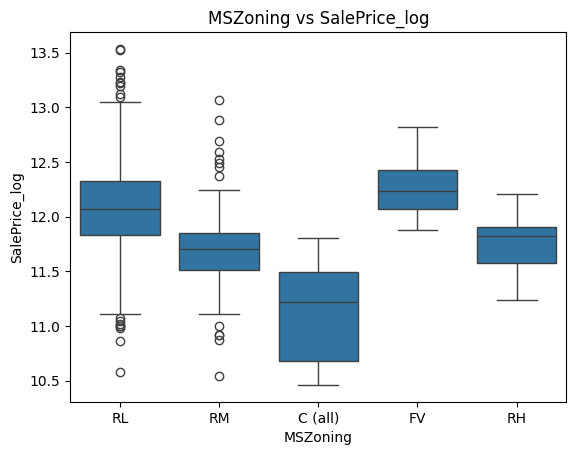

In [32]:
plt.figure()
sns.boxplot(x=train["MSZoning"], y=train["SalePrice_log"])
plt.title("MSZoning vs SalePrice_log")
plt.show()

**Relation entre MSZoning et SalePrice_log**

Le boxplot montre que le type de zonage (`MSZoning`) a un impact sur le prix de vente.

On observe que :
- les zones `FV` présentent les prix médians les plus élevés
- les zones `RL` ont des prix intermédiaires avec une forte dispersion
- les zones `RM` et `RH` ont des prix globalement plus faibles
- la catégorie `C (all)` présente les prix les plus bas

Cela indique que le zonage influence significativement la valeur des biens immobiliers.

Cependant :
- certaines catégories sont peu représentées, ce qui peut introduire du bruit
- la variabilité intra-catégorie reste importante

Conclusion :
`MSZoning` est une variable pertinente pour la modélisation,
mais nécessitera un encodage adapté et éventuellement un regroupement des catégories rares.

In [33]:
train["HouseStyle"].value_counts()

HouseStyle
1Story    726
2Story    443
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

**Analyse de la variable HouseStyle**

La variable `HouseStyle` décrit le type architectural du logement (nombre d’étages, aménagement des combles, etc.).

On observe que :
- les catégories `1Story` et `2Story` sont largement dominantes
- les autres catégories (`1.5Fin`, `SLvl`, etc.) sont beaucoup moins représentées
- certaines catégories sont très rares (ex : `2.5Fin`, `2.5Unf`)

Cela indique une distribution déséquilibrée de la variable.

Ce déséquilibre peut poser problème lors de l’encodage,
car les catégories rares peuvent introduire du bruit ou du surapprentissage.

Il pourra être pertinent de regrouper certaines catégories peu fréquentes
ou d’utiliser un encodage adapté.

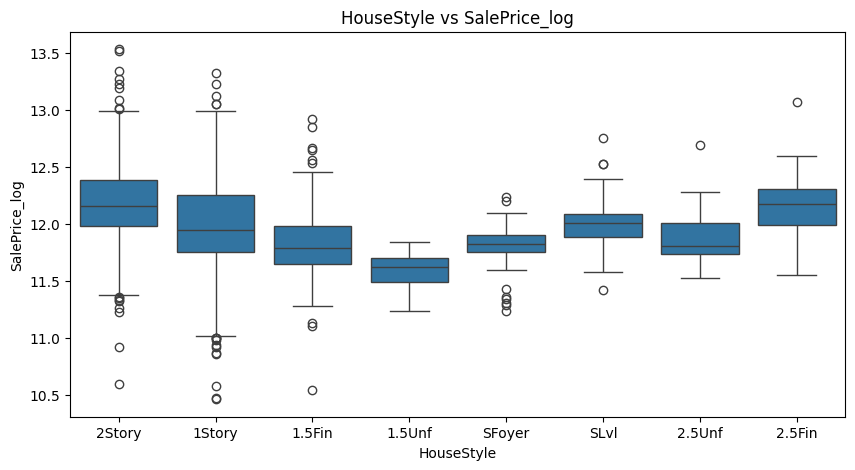

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train["HouseStyle"], y=train["SalePrice_log"])
plt.title("HouseStyle vs SalePrice_log")
plt.show()

**Analyse de la variable HouseStyle**

La variable `HouseStyle` décrit le type architectural du logement (nombre d’étages, aménagement des combles, etc.).

On observe que :
- les catégories `1Story` et `2Story` sont largement dominantes
- les autres catégories (`1.5Fin`, `SLvl`, etc.) sont beaucoup moins représentées
- certaines catégories sont très rares (ex : `2.5Fin`, `2.5Unf`)

Cela indique une distribution déséquilibrée de la variable.

Ce déséquilibre peut poser problème lors de l’encodage,
car les catégories rares peuvent introduire du bruit ou du surapprentissage.

Il pourra être pertinent de regrouper certaines catégories peu fréquentes
ou d’utiliser un encodage adapté.

---

### PIPELINE DATASCIENCE

In [63]:
X = train.drop(columns=["SalePrice", "SalePrice_log", "Id"], errors="ignore")
y = train["SalePrice_log"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(X.shape)
print(len(num_cols), len(cat_cols))

(1458, 78)
35 43


**préprocessing pipeline**

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Pipeline numérique
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Pipeline catégoriel
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#Pipeline global
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("Pipeline prêt")

Pipeline prêt


**split train / validation**

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape)

(1166, 78) (292, 78)


**Premier modèle**

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

print("Modèle entraîné")

Modèle entraîné


***Evaluation du modèle***

In [68]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

y_pred = model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")

RMSE : 0.1356
R2   : 0.8910
MAE  : 0.0931
MSE  : 0.0184


Le coefficient de détermination R² ≈ 0.89 indique que le modèle explique environ 89% de la variance de la variable cible. Cela traduit une bonne capacité de prédiction.

Le RMSE et le MAE sont relativement faibles, ce qui signifie que les erreurs de prédiction restent globalement limitées.

La différence entre RMSE et MAE montre que certaines erreurs plus importantes existent, mais elles restent modérées.

Globalement, le modèle de régression linéaire offre de bonnes performances,
mais il peut encore être amélioré avec des modèles plus complexes capables de capturer des relations non linéaires.

***Random Forest***

In [67]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

mse_rf = mean_squared_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print(f"RMSE : {rmse_rf:.4f}")
print(f"R2   : {r2_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"MSE  : {mse_rf:.4f}")

RMSE : 0.1403
R2   : 0.8832
MAE  : 0.0948
MSE  : 0.0197


**Comparaison des modèles : Régression linéaire vs Random Forest**

Comparé à la régression linéaire :
- le RMSE est légèrement plus élevé
- le MAE est légèrement plus élevé
- le R² est légèrement plus faible

Cela indique que, dans ce cas précis, le modèle de régression linéaire
performe légèrement mieux que le Random Forest.

Interprétation :
- les relations dans les données semblent globalement linéaires
- le feature engineering et la transformation logarithmique ont bien simplifié le problème
- le Random Forest n’apporte pas d’amélioration significative ici

Conclusion :
Le modèle de régression linéaire est retenu comme modèle de base,
car il offre de meilleures performances et une meilleure interprétabilité.

**Cross-Validation**

In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model, X, y,
    scoring="neg_mean_squared_error",
    cv=5
)

rmse_scores = np.sqrt(-scores)

print("RMSE par fold :", rmse_scores)
print("RMSE moyen    :", rmse_scores.mean())
print("Écart-type    :", rmse_scores.std())

RMSE par fold : [0.12375943 0.13736433 0.1389753  0.11058002 0.12311823]
RMSE moyen    : 0.12675946166088756
Écart-type    : 0.01044723145667605


**Validation croisée du modèle de régression linéaire**

La validation croisée (5-fold) permet d’évaluer la robustesse du modèle sur plusieurs sous-échantillons des données.

Résultats :
- RMSE moyen : 0.1268
- Écart-type : 0.0104

Interprétation :
- le RMSE moyen est légèrement inférieur à celui obtenu sur le split validation,
  ce qui confirme de bonnes performances globales
- l’écart-type est faible, indiquant une bonne stabilité du modèle
- les performances sont homogènes entre les différents folds

Conclusion :
Le modèle de régression linéaire est robuste et généralise bien sur les données.
Il constitue donc un bon choix pour la suite du projet.

**GridSearch** *question de voir si la regression linéaire simple suffit*

In [70]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

param_grid = {
    "regressor__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
}

grid = GridSearchCV(
    ridge_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)

print("Best params :", grid.best_params_)

y_pred_ridge = grid.predict(X_val)

mse = mean_squared_error(y_val, y_pred_ridge)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred_ridge)
r2 = r2_score(y_val, y_pred_ridge)

print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")

Best params : {'regressor__alpha': 10.0}
RMSE : 0.1230
R2   : 0.9102
MAE  : 0.0865


**Optimisation du modèle avec Ridge Regression (GridSearch)**

Le modèle Ridge optimisé avec GridSearch donne les résultats suivants :
- Meilleur paramètre : alpha = 10.0
- RMSE : 0.1230
- MAE  : 0.0865
- R²   : 0.9102

Comparé à la régression linéaire :
- le RMSE est plus faible → meilleure précision
- le MAE est plus faible → erreurs globalement réduites
- le R² est plus élevé → meilleure explication de la variance

Interprétation :
- la régularisation Ridge permet de mieux gérer la multicolinéarité
- elle améliore la généralisation du modèle
- elle réduit le surapprentissage

Conclusion :
Le modèle Ridge optimisé est plus performant que la régression linéaire simple.
Il sera retenu comme modèle final pour ce projet.

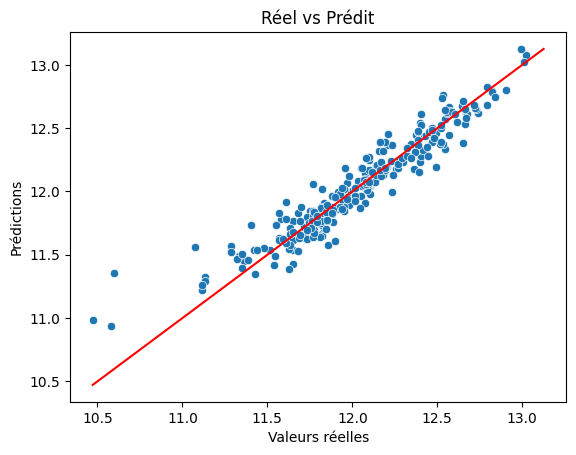

In [71]:
plt.figure()
sns.scatterplot(x=y_val, y=y_pred_ridge)

import numpy as np
min_val = min(y_val.min(), y_pred_ridge.min())
max_val = max(y_val.max(), y_pred_ridge.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Réel vs Prédit")
plt.show()

**Analyse des prédictions avec la droite de référence**

Le nuage de points montre une forte concentration des observations autour de la droite de référence (y = x), qui représente une prédiction parfaite.

On observe que :
- la majorité des points est proche de la diagonale → bonnes prédictions
- la relation entre valeurs réelles et prédites est bien linéaire
- les écarts restent limités → erreurs faibles

Cependant :
- quelques points s’éloignent de la droite, indiquant des erreurs de prédiction
- ces écarts sont plus visibles pour certaines valeurs extrêmes

Conclusion :

Le modèle présente une excellente capacité de prédiction,
avec une bonne adéquation entre les valeurs réelles et les valeurs estimées.

Cela confirme les bons résultats obtenus avec les métriques (RMSE, R²).

---

**Test sur une nouvelle donnée insérée manuellement**

In [72]:
new_house = {
    'MSSubClass': 60,
    'MSZoning': 'RL',
    'LotFrontage': 70.0,
    'LotArea': 9000,
    'Street': 'Pave',
    'Alley': 'None',
    'LotShape': 'Reg',
    'LandContour': 'Lvl',
    'Utilities': 'AllPub',
    'LotConfig': 'Inside',
    'LandSlope': 'Gtl',
    'Neighborhood': 'CollgCr',
    'Condition1': 'Norm',
    'Condition2': 'Norm',
    'BldgType': '1Fam',
    'HouseStyle': '2Story',
    'OverallQual': 7,
    'OverallCond': 5,
    'YearBuilt': 2005,
    'YearRemodAdd': 2005,
    'RoofStyle': 'Gable',
    'RoofMatl': 'CompShg',
    'Exterior1st': 'VinylSd',
    'Exterior2nd': 'VinylSd',
    'MasVnrType': 'BrkFace',
    'MasVnrArea': 150.0,
    'ExterQual': 'Gd',
    'ExterCond': 'TA',
    'Foundation': 'PConc',
    'BsmtQual': 'Gd',
    'BsmtCond': 'TA',
    'BsmtExposure': 'No',
    'BsmtFinType1': 'GLQ',
    'BsmtFinSF1': 500,
    'BsmtFinType2': 'Unf',
    'BsmtFinSF2': 0,
    'BsmtUnfSF': 400,
    'TotalBsmtSF': 900,
    'Heating': 'GasA',
    'HeatingQC': 'Ex',
    'CentralAir': 'Y',
    'Electrical': 'SBrkr',
    '1stFlrSF': 900,
    '2ndFlrSF': 700,
    'LowQualFinSF': 0,
    'GrLivArea': 1600,
    'BsmtFullBath': 1,
    'BsmtHalfBath': 0,
    'FullBath': 2,
    'HalfBath': 1,
    'BedroomAbvGr': 3,
    'KitchenAbvGr': 1,
    'KitchenQual': 'Gd',
    'TotRmsAbvGrd': 7,
    'Functional': 'Typ',
    'Fireplaces': 1,
    'FireplaceQu': 'TA',
    'GarageType': 'Attchd',
    'GarageYrBlt': 2005,
    'GarageFinish': 'RFn',
    'GarageCars': 2,
    'WoodDeckSF': 100,
    'OpenPorchSF': 40,
    'EnclosedPorch': 0,
    '3SsnPorch': 0,
    'ScreenPorch': 0,
    'PoolArea': 0,
    'PoolQC': 'None',
    'Fence': 'None',
    'MiscFeature': 'None',
    'MiscVal': 0,
    'MoSold': 6,
    'YrSold': 2010,
    'SaleType': 'WD',
    'SaleCondition': 'Normal'
}

new_house_df = pd.DataFrame([new_house])
new_house_df = new_house_df.reindex(columns=X.columns)

print("NaN restants :", new_house_df.isna().sum().sum())

pred_log = grid.predict(new_house_df)[0]
pred_price = np.expm1(pred_log)

print("Prédiction log :", round(pred_log, 4))
print("Prix prédit    :", round(pred_price, 2))

NaN restants : 3
Prédiction log : 12.2388
Prix prédit    : 206663.08


**Test du modèle sur une nouvelle donnée saisie manuellement**

Une nouvelle observation a été créée manuellement en respectant le schéma des variables d’entrée du modèle.

Après passage dans le pipeline de prétraitement puis dans le modèle Ridge optimisé, la prédiction obtenue est :

- Prédiction sur l’échelle logarithmique : 12.2388
- Prix estimé après transformation inverse : 206663.08

Cette valeur est cohérente avec les caractéristiques du bien renseigné :
- maison individuelle
- quartier résidentiel (`CollgCr`)
- qualité globale correcte (`OverallQual = 7`)
- surface habitable moyenne à bonne (`GrLivArea = 1600`)
- garage de 2 places

Ce test montre que le pipeline complet fonctionne correctement sur une nouvelle donnée non observée pendant l’entraînement.

Le modèle est donc capable d’être utilisé pour prédire le prix d’un bien immobilier à partir de ses caractéristiques.

---

**Sauvegarder le modèle avec `joblib`**

In [73]:
import joblib

joblib.dump(grid, "ridge_house_price_model.joblib")
print("Modèle sauvegardé")

Modèle sauvegardé


*Chargement + test*

In [74]:
loaded_model = joblib.load("ridge_house_price_model.joblib")

pred_log = loaded_model.predict(new_house_df)[0]
pred_price = np.expm1(pred_log)

print("Prix prédit :", round(pred_price, 2))

Prix prédit : 206663.08


**Sauvegarde du modèle**

Le modèle final a été sauvegardé au format `joblib` afin de pouvoir être réutilisé sans réentraînement.

Cette étape permet de conserver :
- le pipeline de prétraitement
- le modèle optimisé
- la logique complète de prédiction

Le chargement du fichier sauvegardé permet ensuite d’effectuer directement de nouvelles prédictions sur des données inédites.